# Coulomb + Viscous Friction Model — Svaya 6-DOF Cobot
## Joints 1 · 2 · 3 · 5  |  CSIR-CMERI Internship  |  Gear Ratio N = 100

---

### Physics Model

$$v_{\text{eff}} = v + C_p \cdot q$$

$$\boxed{\tau_f = T_c \cdot \tanh\!\left(\frac{v_{\text{eff}}}{V_s}\right) + B_v \cdot v_{\text{eff}} + C_0}$$

### Friction Torque Label (Gear Ratio Applied)

$$\tau_f = N \cdot \tau_{\text{motor}} - (-\tau_{\text{joint}}) \qquad N = 100$$

| Symbol | Physical meaning | Unit |
|--------|-----------------|------|
| $N$ | Gear ratio (100 : 1) | — |
| $T_c$ | Coulomb friction amplitude | N·mm |
| $B_v$ | Viscous damping coefficient | N·mm·s/rad |
| $V_s$ | Stribeck velocity scale | rad/s |
| $C_p$ | Position coupling — $v_{\text{eff}} = v + C_p q$ | — |
| $C_0$ | Static offset (gravity / load bias) | N·mm |

---
> **Model simplification:** The pre-computed `velocity` CSV column (dq/dt) is **not used**  
> because position $q$ already encodes the same information via the coupling term $C_p \cdot q$.  
> Using both would introduce redundancy and inflate parameter uncertainty.

> **Note on Joint 2 RMSE:** J2 has only ~4 100 rows with high intrinsic noise  
> (polynomial noise-floor RMSE ≈ 7.5 N·mm on ±36 N·mm range). The physics model  
> achieving RMSE ≈ 8.1 is consistent with this limit — this is not an optimiser failure.

---
**Optimiser:** `scipy.optimize.least_squares` · `method='trf'` · `loss='soft_l1'` (Huber NLS)  
**Parameter scaling:** every param normalised to O(1) before fitting → no vanishing gradients  
**Data split:** Train 70 % · Val 10 % · Test 20 % (shuffle, seed = 42)  
**Metrics:** MSE · RMSE · MAE [N·mm]


## ① Imports

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


# Working On Repetitive Dataset
## ② Configuration — Update File Paths

In [32]:
FILE_PATHS = {
    1: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Cleaned_Data_With_Vel\1_Vel.csv",   # Joint 1  (~47 000 rows)
    2: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Cleaned_Data_With_Vel\2_Vel.csv",   # Joint 2  (~ 4 100 rows)
    3: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Cleaned_Data_With_Vel\3_Vel.csv",   # Joint 3  (~11 600 rows)
    5: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Cleaned_Data_With_Vel\5_Vel.csv",   # Joint 5  (~32 000 rows)
}
# ─────────────────────────────────────────────────────────────────────────────

JOINTS = [1, 2, 3, 5]
N = 100
RANDOM_STATE = 42
print(f"Gear ratio N = {N}  Joints = {JOINTS}")

Gear ratio N = 100  Joints = [1, 2, 3, 5]


## ③ Data Loading & Preprocessing

In [33]:
def load_joint(joint, filepath, N=100):
    """
    Load one joint CSV, convert units, compute friction torque label.

    Columns used
    ------------
    v{j}     Joint velocity   [deg/s]  → rad/s
    q{j}     Joint position   [deg]    → rad
    m_t_{j}  Motor torque              [N·mm]
    jts{j}   Joint torque sensor       [N·mm]

    NOTE: The pre-computed `velocity` CSV column is intentionally NOT used.
    Position q already captures the same information via the Cp coupling term
    in v_eff = v + Cp*q.

    Returns
    -------
    X  : ndarray (n, 2)   columns = [v [rad/s],  q [rad]]
    y  : ndarray (n,)     tf  [N·mm]
    df : cleaned DataFrame
    """

    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df["v"]  = np.deg2rad(df[f"v{joint}"]) # rad/s
    df["q"]  = np.deg2rad(df[f"q{joint}"]) # rad
    df["tm"] = df[f"m_t_{joint}"] # N·mm
    df["tj"] = df[f"jts{joint}"] # N·mm
    df["tf"] = N * df["tm"] - (-df["tj"]) # N·mm

    df.dropna(subset=["v", "q", "tf"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    X = df[["v", "q"]].values # (n, 2)
    y = df["tf"].values # (n,)
    return X, y, df


# ── Load all joints & print data
joint_data = {}

print(f"{'Jt':>3}    {'Rows':>7}    {'tf_min':>9}    {'tf_max':>9}    {'tf_mean':>9}    {'corr(v, tf)':>11}    {'corr(q, tf)':>11}")

for j in JOINTS:
    X, y, df = load_joint(j, FILE_PATHS[j], N=N)
    joint_data[j] = (X, y, df)
    cv = np.corrcoef(X[:, 0], y)[0, 1]
    cq = np.corrcoef(X[:, 1], y)[0, 1]
    print(f"  {j:1d}    {len(y):>7d}    {y.min():>9.3f}    {y.max():>9.3f}"
          f"    {y.mean():>9.4f}  {cv:>+11.4f}  {cq:>+11.4f}    N·mm")

 Jt       Rows       tf_min       tf_max      tf_mean    corr(v, tf)    corr(q, tf)
  1      47265      -26.152       28.098       0.7828      +0.9768      -0.0342    N·mm
  2       4129      -36.151       33.765      -1.1907      +0.7553      +0.6267    N·mm
  3      11602      -18.672       17.260      -0.6946      +0.8034      +0.5463    N·mm
  5      32023       -5.377        5.528      -0.1667      +0.9243      +0.1738    N·mm


## ④ Physics Model & Optimiser

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# PHYSICS MODEL
# ─────────────────────────────────────────────────────────────────────────────
def friction_model(ps, sc, X):
    """
    Coulomb + Viscous + Position friction model  (parameter-scaled form).

    v_eff = v + Cp * q
    tf    = Tc * tanh(v_eff / Vs) +  Bv * v_eff + C0

    Parameters stored as ps[i]  (O(1) during optimisation).
    True values = ps[i] * sc[i].

    Index  Symbol   Unit
    -----  ------   ----
      0      Tc     N·mm        Coulomb friction amplitude
      1      Bv     N·mm·s/rad  Viscous damping coefficient
      2      Vs     rad/s       Stribeck velocity scale
      3      Cp     —           Joint position coupling
      4      C0     N·mm        Static offset (gravity / load bias)

    X columns: [v [rad/s],  q [rad]]
    """

    Tc = ps[0] * sc[0]
    Bv = ps[1] * sc[1]
    Vs = ps[2] * sc[2]
    Cp = ps[3] * sc[3]
    C0 = ps[4] * sc[4]

    v, q  = X[:, 0], X[:, 1]
    v_eff = v + Cp * q
    return Tc * np.tanh(v_eff / Vs) + Bv * v_eff + C0


# ─────────────────────────────────────────────────────────────────────────────
# OPTIMISER
# ─────────────────────────────────────────────────────────────────────────────
def fit_joint(X_train, y_train):
    """
    Robust Nonlinear Least Squares.

    Key decisions
    -------------
    1. method='trf'   — Trust Region Reflective; handles bounds, large datasets.
    2. loss='soft_l1' — Huber-like; L2 for small residuals, L1 for large ones. Avoids the gradient-collapse seen with pure L2 (curve_fit).
    3. Scaled params  — Tc ~ O(10), Vs ~ O(0.01): 3 orders apart. Normalising brings all to O(1) → well-conditioned Jacobian.
    4. C0 offset      — Absorbs gravity bias amplified by gear ratio N=100.

    Returns
    -------
    result : OptimizeResult (result.x are the SCALED params)
    scale  : 1-D array of scale factors
    """

    Tc_init = np.percentile(np.abs(y_train), 85) # Data-driven Coulomb seed
    C0_init = float(np.mean(y_train)) # Data-driven offset seed
    C0_sc = max(abs(C0_init), 0.01)

    # Scale: true param = scaled param × scale  →  scaled param ≈ 1
    scale = np.array([Tc_init, 50.0, 0.05, 1.0, C0_sc]) # s_Tc, s_Bvm s_Vs, s_Cp, s_C0

    p0    = np.array([1.0, 0.5, 1.0, 0.0, float(np.sign(C0_init)) if C0_init != 0 else 0.0])

    lb = [1e-6 / scale[0], # Tc > 0
          1e-6 / scale[1], # Bv > 0
          1e-6 / scale[2], # Vs > 5e-8 rad/s  (prevents tanh(v/0) blow-up)
          -np.inf, # Cp unconstrained
          -np.inf] # C0 unconstrained
    ub = [np.inf] * 5

    result = least_squares(
        lambda ps, sc, X, y: friction_model(ps, sc, X) - y,
        p0,
        args=(scale, X_train, y_train),
        bounds=(lb, ub),
        method="trf",
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=8000,
        ftol=1e-12, xtol=1e-12, gtol=1e-12,
        verbose=0
    )
    return result, scale


def predict(result, scale, X):
    return friction_model(result.x, scale, X)


def metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    return mse, np.sqrt(mse), mean_absolute_error(y_true, y_pred)


print("Model and optimiser ready.")

Model and optimiser ready.


## ⑤ Joint 1

- corr(v,tf) ≈ +0.977 — velocity dominant after N=100  
- tf_mean ≈ +0.91 N·mm (gravity bias) → captured by C₀


In [35]:
j = 1
X, y, _ = joint_data[j]

# ── Split ─────────────────────────────────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=2/3, random_state=RANDOM_STATE, shuffle=True)
print(f"J{j}  Train={len(y_tr)}  Val={len(y_val)}  Test={len(y_te)}")

# ── Fit ───────────────────────────────────────────────────────────────────
result_1, scale_1 = fit_joint(X_tr, y_tr)
Tc, Bv, Vs, Cp, C0 = [result_1.x[i] * scale_1[i] for i in range(5)]

print(f"\n  Estimated Parameters — Joint {j}")
print(f"Tc = {Tc:>14.5f}  N·mm        Coulomb friction amplitude")
print(f"Bv = {Bv:>14.5f}  N·mm·s/rad  Viscous damping coefficient")
print(f"Vs = {Vs:>14.6f}  rad/s       Stribeck velocity scale")
print(f"Cp = {Cp:>14.5f}              Position coupling (v_eff = v + Cp*q)")
print(f"C0 = {C0:>14.5f}  N·mm        Static offset")

# ── Predict & Metrics ─────────────────────────────────────────────────────
val_pred_1  = predict(result_1, scale_1, X_val)
test_pred_1 = predict(result_1, scale_1, X_te)

mse_v1, rmse_v1, mae_v1 = metrics(y_val, val_pred_1)
mse_t1, rmse_t1, mae_t1 = metrics(y_te,  test_pred_1)

print(f"\n{'-'*50}")
print(f"{' Set':<14}  {' MSE':>10}  {'RMSE':>8}  {'MAE':>8}  [N·mm]")
print(f"{'-'*50}")
print(f"{'Validation':<14}  {mse_v1:>10.4f}  {rmse_v1:>8.4f}  {mae_v1:>8.4f}")
print(f"{'Test':<14}  {mse_t1:>10.4f}  {rmse_t1:>8.4f}  {mae_t1:>8.4f}")
print(f"\nPred range : [{test_pred_1.min():.3f}, {test_pred_1.max():.3f}]  N·mm")
print(f"Actual range : [{y_te.min():.3f}, {y_te.max():.3f}]  N·mm")

J1  Train=33085  Val=4726  Test=9454

  Estimated Parameters — Joint 1
Tc =       10.55285  N·mm        Coulomb friction amplitude
Bv =       15.75698  N·mm·s/rad  Viscous damping coefficient
Vs =       0.005887  rad/s       Stribeck velocity scale
Cp =        0.00131              Position coupling (v_eff = v + Cp*q)
C0 =        0.91275  N·mm        Static offset

--------------------------------------------------
 Set                   MSE      RMSE       MAE  [N·mm]
--------------------------------------------------
Validation          5.5859    2.3634    1.8027
Test                5.5211    2.3497    1.8016

Pred range : [-22.208, 24.040]  N·mm
Actual range : [-26.152, 27.595]  N·mm


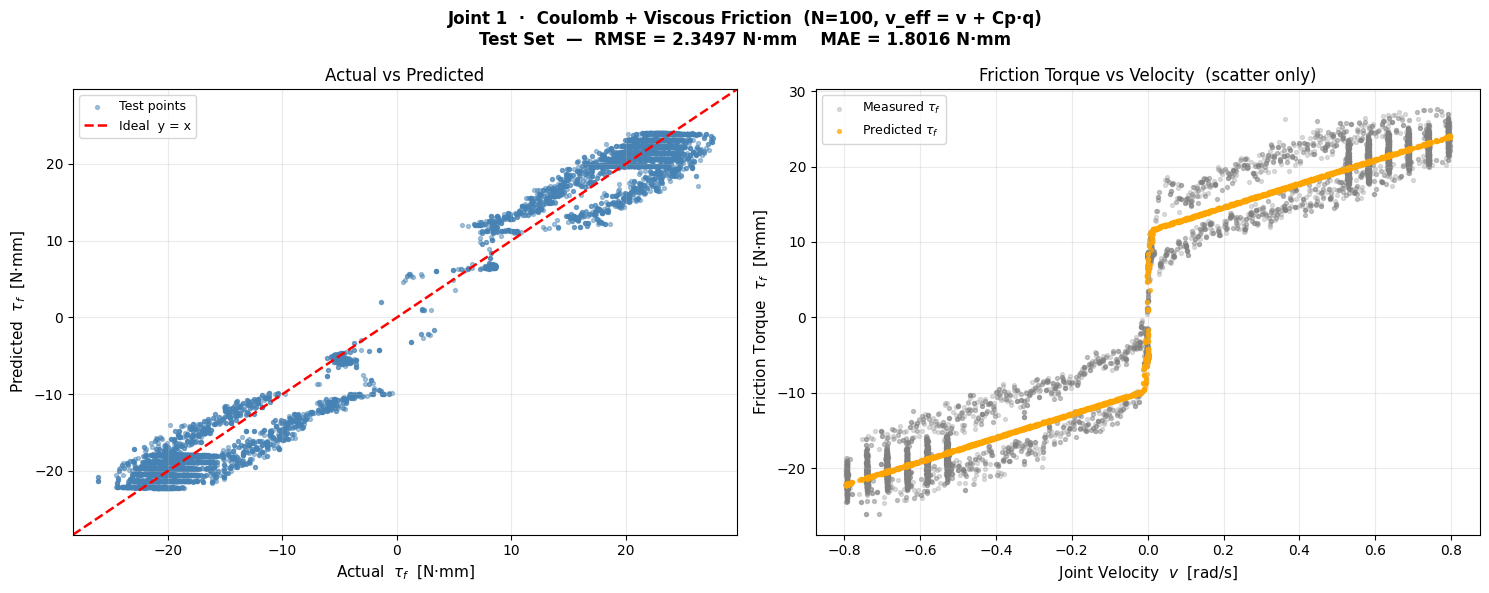

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Joint 1  ·  Coulomb + Viscous Friction  (N=100, v_eff = v + Cp·q)\n"
    f"Test Set  —  RMSE = {rmse_t1:.4f} N·mm    MAE = {mae_t1:.4f} N·mm",
    fontsize=12, fontweight="bold"
)

# Left: Actual vs Predicted
ax = axes[0]
ax.scatter(y_te, test_pred_1, s=8, alpha=0.45, color="steelblue", label="Test points")
lo = min(y_te.min(), test_pred_1.min())
hi = max(y_te.max(), test_pred_1.max())
pad = (hi - lo) * 0.04
ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], "r--", lw=1.8, label="Ideal  y = x")
ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
ax.set_xlabel(r"Actual  $\tau_f$  [N·mm]", fontsize=11)
ax.set_ylabel(r"Predicted  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Actual vs Predicted", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# Right: tf vs velocity (scatter plot)
ax = axes[1]
ax.scatter(X_te[:, 0], y_te, s=8, alpha=0.25, color="gray", label=r"Measured $\tau_f$")
ax.scatter(X_te[:, 0], test_pred_1,  s=8, alpha=0.65, color="orange", label=r"Predicted $\tau_f$")
ax.set_xlabel(r"Joint Velocity  $v$  [rad/s]", fontsize=11)
ax.set_ylabel(r"Friction Torque  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Friction Torque vs Velocity  (scatter only)", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## ⑥ Joint 2
 
- corr(v,tf) ≈ +0.755, corr(q,tf) ≈ +0.627 — both matter  
- Polynomial noise-floor RMSE ≈ 7.5 N·mm; physics model RMSE ~8 is at the data limit


In [37]:
j = 2
X, y, _ = joint_data[j]

# ── Split ─────────────────────────────────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=2/3, random_state=RANDOM_STATE, shuffle=True)
print(f"J{j}  Train={len(y_tr)}  Val={len(y_val)}  Test={len(y_te)}")

# ── Fit ───────────────────────────────────────────────────────────────────
result_2, scale_2 = fit_joint(X_tr, y_tr)
Tc, Bv, Vs, Cp, C0 = [result_2.x[i] * scale_2[i] for i in range(5)]

print(f"\nEstimated Parameters — Joint {j}")
print(f"Tc = {Tc:>14.5f}  N·mm        Coulomb friction amplitude")
print(f"Bv = {Bv:>14.5f}  N·mm·s/rad  Viscous damping coefficient")
print(f"Vs = {Vs:>14.6f}  rad/s       Stribeck velocity scale")
print(f"Cp = {Cp:>14.5f}              Position coupling (v_eff = v + Cp*q)")
print(f"C0 = {C0:>14.5f}  N·mm        Static offset")

# ── Predict & Metrics ─────────────────────────────────────────────────────
val_pred_2  = predict(result_2, scale_2, X_val)
test_pred_2 = predict(result_2, scale_2, X_te)

mse_v2, rmse_v2, mae_v2 = metrics(y_val, val_pred_2)
mse_t2, rmse_t2, mae_t2 = metrics(y_te,  test_pred_2)

print(f"\n{'-'*50}")
print(f"{' Set':<14}  {' MSE':>10}  {'RMSE':>8}  {'MAE':>8}  [N·mm]")
print(f"{'-'*50}")
print(f"{'Validation':<14}  {mse_v2:>10.4f}  {rmse_v2:>8.4f}  {mae_v2:>8.4f}")
print(f"{'Test':<14}  {mse_t2:>10.4f}  {rmse_t2:>8.4f}  {mae_t2:>8.4f}")
print(f"\nPred range : [{test_pred_2.min():.3f}, {test_pred_2.max():.3f}]  N·mm")
print(f"Actual range : [{y_te.min():.3f}, {y_te.max():.3f}]  N·mm")

J2  Train=2890  Val=413  Test=826

Estimated Parameters — Joint 2
Tc =        1.50584  N·mm        Coulomb friction amplitude
Bv =       33.40991  N·mm·s/rad  Viscous damping coefficient
Vs =       0.017231  rad/s       Stribeck velocity scale
Cp =        0.54842              Position coupling (v_eff = v + Cp*q)
C0 =       -0.37830  N·mm        Static offset

--------------------------------------------------
 Set                   MSE      RMSE       MAE  [N·mm]
--------------------------------------------------
Validation         77.2881    8.7914    6.0223
Test               64.9598    8.0598    5.5286

Pred range : [-33.650, 32.807]  N·mm
Actual range : [-36.151, 33.765]  N·mm


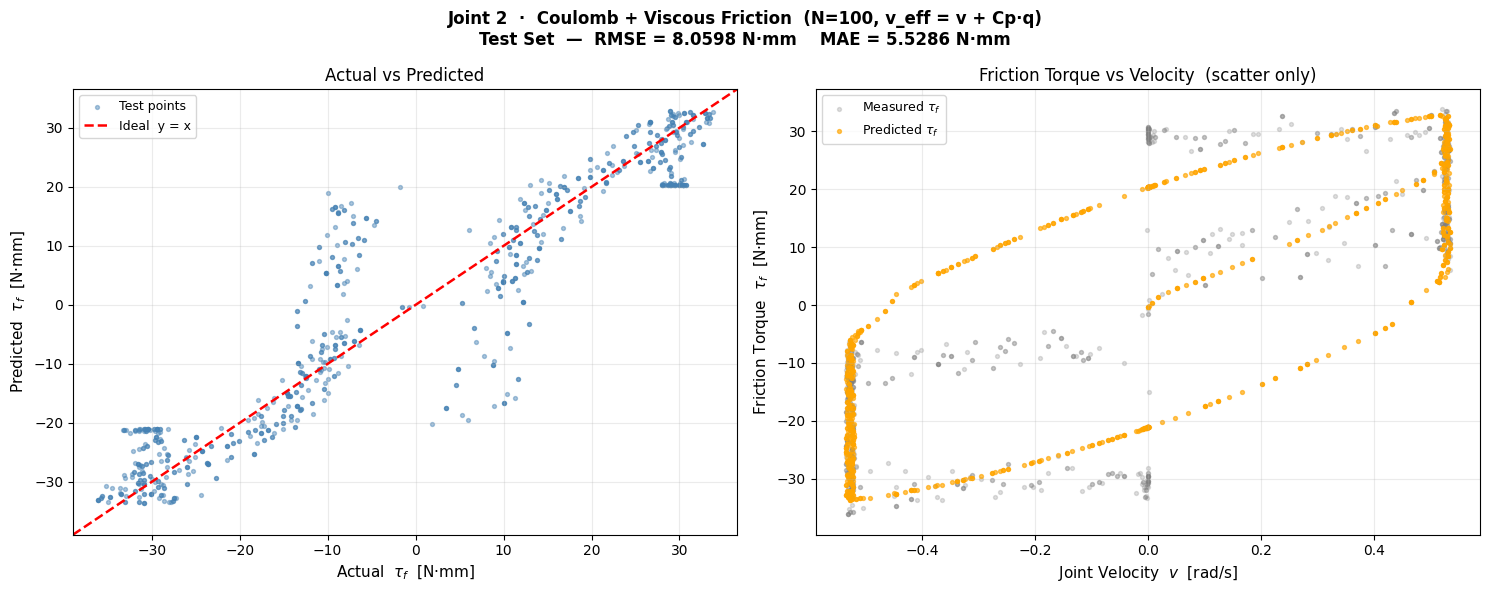

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Joint 2  ·  Coulomb + Viscous Friction  (N=100, v_eff = v + Cp·q)\n"
    f"Test Set  —  RMSE = {rmse_t2:.4f} N·mm    MAE = {mae_t2:.4f} N·mm",
    fontsize=12, fontweight="bold"
)

# Left: Actual vs Predicted
ax = axes[0]
ax.scatter(y_te, test_pred_2, s=8, alpha=0.45, color="steelblue", label="Test points")
lo = min(y_te.min(), test_pred_2.min())
hi = max(y_te.max(), test_pred_2.max())
pad = (hi - lo) * 0.04
ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], "r--", lw=1.8, label="Ideal  y = x")
ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
ax.set_xlabel(r"Actual  $\tau_f$  [N·mm]", fontsize=11)
ax.set_ylabel(r"Predicted  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Actual vs Predicted", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# Right: tf vs velocity (scatter plot)
ax = axes[1]
ax.scatter(X_te[:, 0], y_te, s=8, alpha=0.25, color="gray", label=r"Measured $\tau_f$")
ax.scatter(X_te[:, 0], test_pred_2,  s=8, alpha=0.65, color="orange", label=r"Predicted $\tau_f$")
ax.set_xlabel(r"Joint Velocity  $v$  [rad/s]", fontsize=11)
ax.set_ylabel(r"Friction Torque  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Friction Torque vs Velocity  (scatter only)", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## ⑦ Joint 3
 
- corr(v,tf) ≈ +0.803, corr(q,tf) ≈ +0.546  
- Combined: linear R² ≈ 0.91 → good physics coverage


In [39]:
j = 3
X, y, _ = joint_data[j]

# ── Split ─────────────────────────────────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=2/3, random_state=RANDOM_STATE, shuffle=True)
print(f"J{j}  Train={len(y_tr)}  Val={len(y_val)}  Test={len(y_te)}")

# ── Fit ───────────────────────────────────────────────────────────────────
result_3, scale_3 = fit_joint(X_tr, y_tr)
Tc, Bv, Vs, Cp, C0 = [result_3.x[i] * scale_3[i] for i in range(5)]

print(f"\nEstimated Parameters — Joint {j}")
print(f"Tc = {Tc:>14.5f}  N·mm        Coulomb friction amplitude")
print(f"Bv = {Bv:>14.5f}  N·mm·s/rad  Viscous damping coefficient")
print(f"Vs = {Vs:>14.6f}  rad/s       Stribeck velocity scale")
print(f"Cp = {Cp:>14.5f}              Position coupling (v_eff = v + Cp*q)")
print(f"C0 = {C0:>14.5f}  N·mm        Static offset")

# ── Predict & Metrics ─────────────────────────────────────────────────────
val_pred_3  = predict(result_3, scale_3, X_val)
test_pred_3 = predict(result_3, scale_3, X_te)

mse_v3, rmse_v3, mae_v3 = metrics(y_val, val_pred_3)
mse_t3, rmse_t3, mae_t3 = metrics(y_te,  test_pred_3)

print(f"\n{'-'*50}")
print(f"{' Set':<14}  {' MSE':>10}  {'RMSE':>8}  {'MAE':>8}  [N·mm]")
print(f"{'-'*50}")
print(f"{'Validation':<14}  {mse_v3:>10.4f}  {rmse_v3:>8.4f}  {mae_v3:>8.4f}")
print(f"{'Test':<14}  {mse_t3:>10.4f}  {rmse_t3:>8.4f}  {mae_t3:>8.4f}")
print(f"\nPred range : [{test_pred_3.min():.3f}, {test_pred_3.max():.3f}]  N·mm")
print(f"Actual range : [{y_te.min():.3f}, {y_te.max():.3f}]  N·mm")

J3  Train=8121  Val=1160  Test=2321

Estimated Parameters — Joint 3
Tc =        0.26492  N·mm        Coulomb friction amplitude
Bv =       15.42444  N·mm·s/rad  Viscous damping coefficient
Vs =       0.000983  rad/s       Stribeck velocity scale
Cp =        0.34574              Position coupling (v_eff = v + Cp*q)
C0 =       -0.43026  N·mm        Static offset

--------------------------------------------------
 Set                   MSE      RMSE       MAE  [N·mm]
--------------------------------------------------
Validation         13.0642    3.6144    2.4579
Test               11.5259    3.3950    2.3057

Pred range : [-18.363, 17.338]  N·mm
Actual range : [-18.672, 17.164]  N·mm


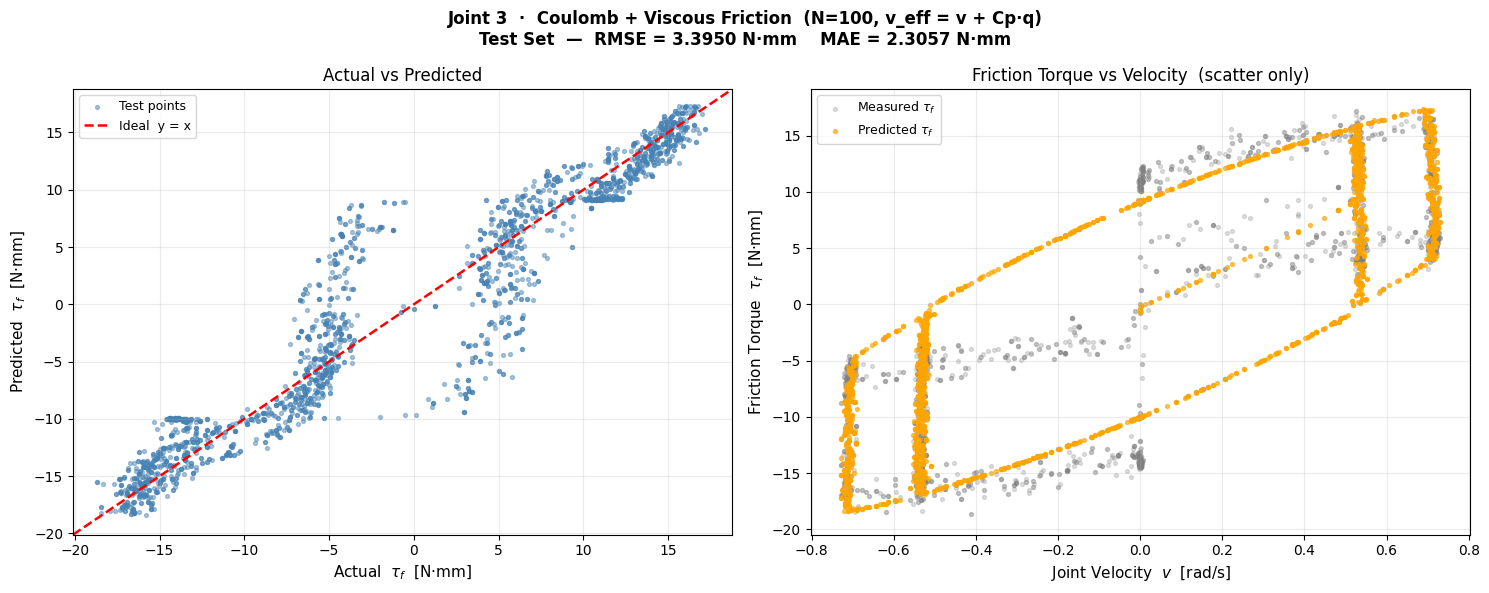

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Joint 3  ·  Coulomb + Viscous Friction  (N=100, v_eff = v + Cp·q)\n"
    f"Test Set  —  RMSE = {rmse_t3:.4f} N·mm    MAE = {mae_t3:.4f} N·mm",
    fontsize=12, fontweight="bold"
)

# Left: Actual vs Predicted
ax = axes[0]
ax.scatter(y_te, test_pred_3, s=8, alpha=0.45, color="steelblue", label="Test points")
lo = min(y_te.min(), test_pred_3.min())
hi = max(y_te.max(), test_pred_3.max())
pad = (hi - lo) * 0.04
ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], "r--", lw=1.8, label="Ideal  y = x")
ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
ax.set_xlabel(r"Actual  $\tau_f$  [N·mm]", fontsize=11)
ax.set_ylabel(r"Predicted  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Actual vs Predicted", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# Right: tf vs velocity (scatter plot)
ax = axes[1]
ax.scatter(X_te[:, 0], y_te, s=8, alpha=0.25, color="gray", label=r"Measured $\tau_f$")
ax.scatter(X_te[:, 0], test_pred_3,  s=8, alpha=0.65, color="orange", label=r"Predicted $\tau_f$")
ax.set_xlabel(r"Joint Velocity  $v$  [rad/s]", fontsize=11)
ax.set_ylabel(r"Friction Torque  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Friction Torque vs Velocity  (scatter only)", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## ⑧ Joint 5

- corr(v,tf) ≈ +0.924 — strongly velocity-driven  
- Smallest tf range (±5.5 N·mm); model RMSE ~0.46 is excellent


In [41]:
j = 5
X, y, _ = joint_data[j]

# ── Split ─────────────────────────────────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=2/3, random_state=RANDOM_STATE, shuffle=True)
print(f"J{j}  Train={len(y_tr)}  Val={len(y_val)}  Test={len(y_te)}")

# ── Fit ───────────────────────────────────────────────────────────────────
result_5, scale_5 = fit_joint(X_tr, y_tr)
Tc, Bv, Vs, Cp, C0 = [result_5.x[i] * scale_5[i] for i in range(5)]

print(f"\n  Estimated Parameters — Joint {j}")
print(f"Tc = {Tc:>14.5f}  N·mm        Coulomb friction amplitude")
print(f"Bv = {Bv:>14.5f}  N·mm·s/rad  Viscous damping coefficient")
print(f"Vs = {Vs:>14.6f}  rad/s       Stribeck velocity scale")
print(f"Cp = {Cp:>14.5f}              Position coupling (v_eff = v + Cp*q)")
print(f"C0 = {C0:>14.5f}  N·mm        Static offset")

# ── Predict & Metrics ─────────────────────────────────────────────────────
val_pred_5  = predict(result_5, scale_5, X_val)
test_pred_5 = predict(result_5, scale_5, X_te)

mse_v5, rmse_v5, mae_v5 = metrics(y_val, val_pred_5)
mse_t5, rmse_t5, mae_t5 = metrics(y_te,  test_pred_5)

print(f"\n{'-'*50}")
print(f"{' Set':<14}  {' MSE':>10}  {'RMSE':>8}  {'MAE':>8}  [N·mm]")
print(f"{'-'*50}")
print(f"{'Validation':<14}  {mse_v5:>10.4f}  {rmse_v5:>8.4f}  {mae_v5:>8.4f}")
print(f"{'Test':<14}  {mse_t5:>10.4f}  {rmse_t5:>8.4f}  {mae_t5:>8.4f}")
print(f"\n Pred range : [{test_pred_5.min():.3f}, {test_pred_5.max():.3f}]  N·mm")
print(f"Actual range : [{y_te.min():.3f}, {y_te.max():.3f}]  N·mm")

J5  Train=22416  Val=3202  Test=6405

  Estimated Parameters — Joint 5
Tc =        3.16432  N·mm        Coulomb friction amplitude
Bv =        1.38923  N·mm·s/rad  Viscous damping coefficient
Vs =       0.004955  rad/s       Stribeck velocity scale
Cp =        0.00399              Position coupling (v_eff = v + Cp*q)
C0 =       -0.10019  N·mm        Static offset

--------------------------------------------------
 Set                   MSE      RMSE       MAE  [N·mm]
--------------------------------------------------
Validation          0.2118    0.4602    0.3530
Test                0.2068    0.4548    0.3496

 Pred range : [-4.373, 4.181]  N·mm
Actual range : [-5.377, 5.321]  N·mm


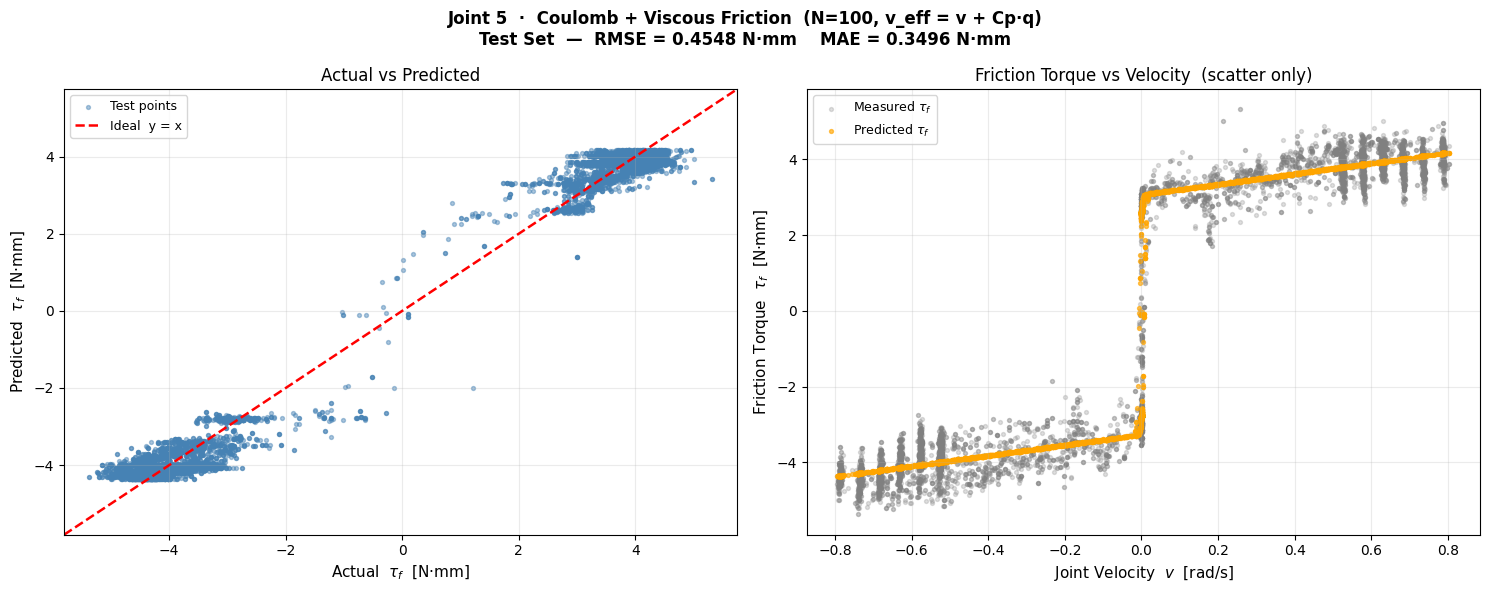

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Joint 5  ·  Coulomb + Viscous Friction  (N=100, v_eff = v + Cp·q)\n"
    f"Test Set  —  RMSE = {rmse_t5:.4f} N·mm    MAE = {mae_t5:.4f} N·mm",
    fontsize=12, fontweight="bold"
)

# Left: Actual vs Predicted
ax = axes[0]
ax.scatter(y_te, test_pred_5, s=8, alpha=0.45, color="steelblue", label="Test points")
lo = min(y_te.min(), test_pred_5.min())
hi = max(y_te.max(), test_pred_5.max())
pad = (hi - lo) * 0.04
ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], "r--", lw=1.8, label="Ideal  y = x")
ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
ax.set_xlabel(r"Actual  $\tau_f$  [N·mm]", fontsize=11)
ax.set_ylabel(r"Predicted  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Actual vs Predicted", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# Right: tf vs velocity (scatter plot)
ax = axes[1]
ax.scatter(X_te[:, 0], y_te, s=8, alpha=0.25, color="gray", label=r"Measured $\tau_f$")
ax.scatter(X_te[:, 0], test_pred_5,  s=8, alpha=0.65, color="orange", label=r"Predicted $\tau_f$")
ax.set_xlabel(r"Joint Velocity  $v$  [rad/s]", fontsize=11)
ax.set_ylabel(r"Friction Torque  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Friction Torque vs Velocity  (scatter only)", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## ⑨ Combined View — All Joints (tf vs Velocity)

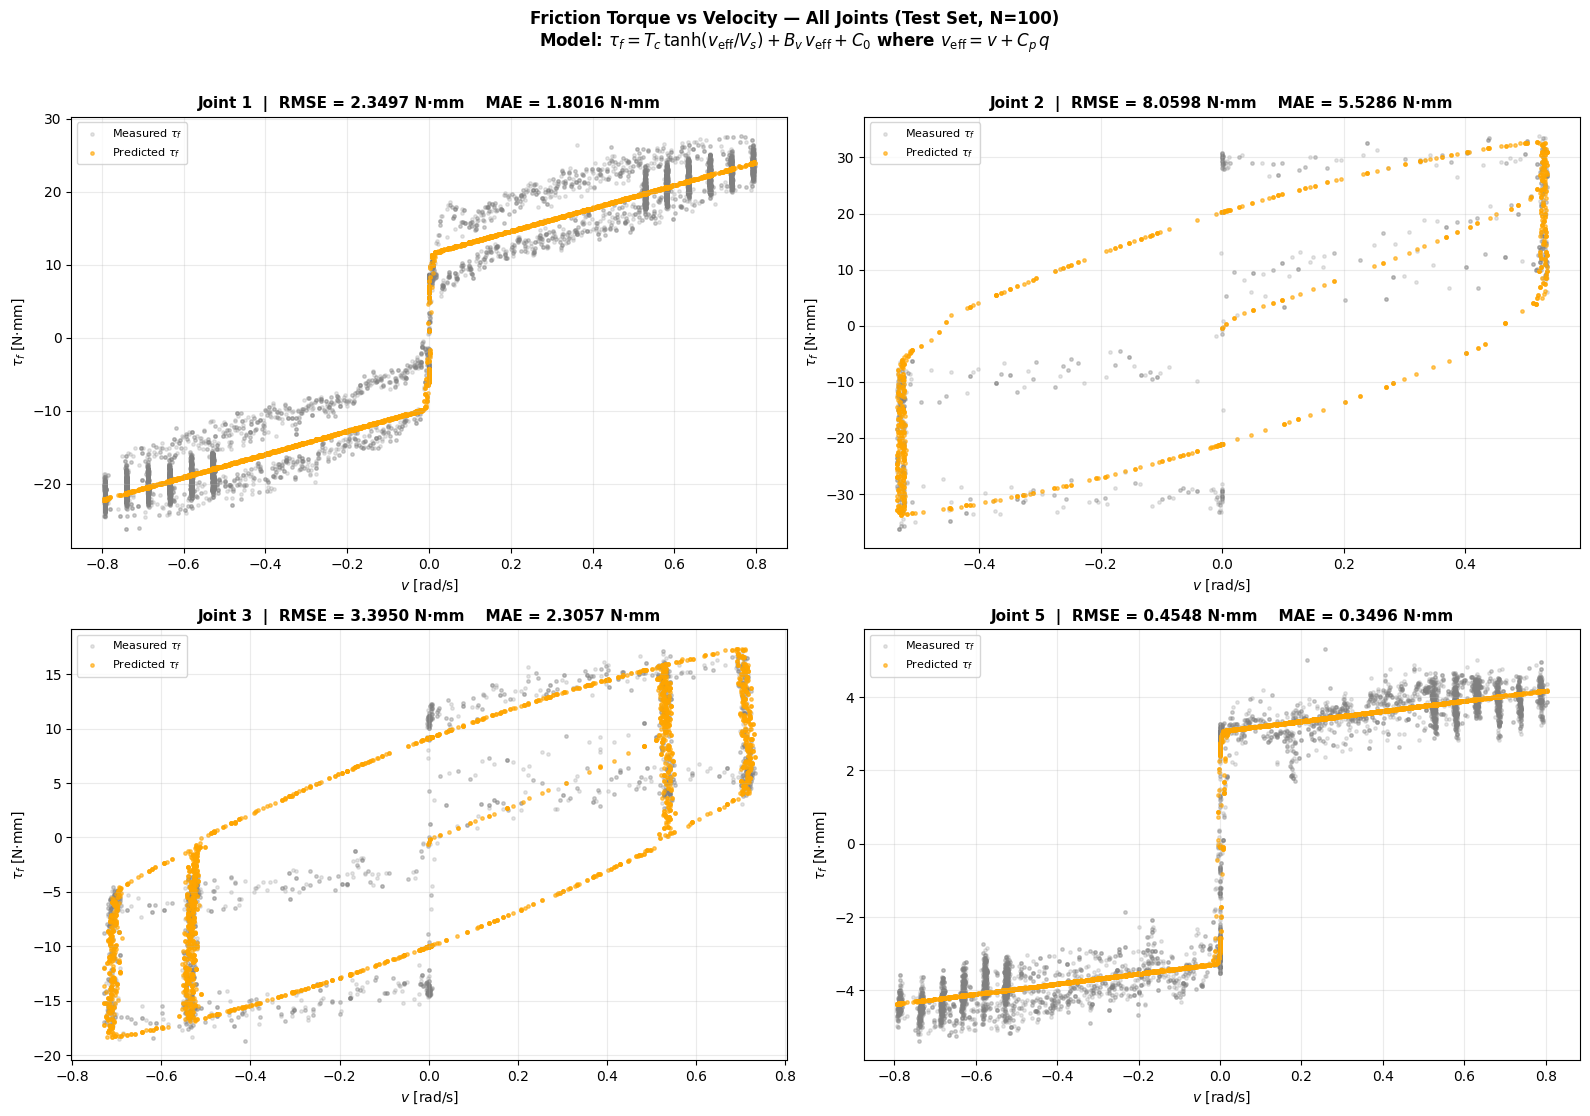

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

_info = [
    (1, result_1, scale_1, rmse_t1, mae_t1),
    (2, result_2, scale_2, rmse_t2, mae_t2),
    (3, result_3, scale_3, rmse_t3, mae_t3),
    (5, result_5, scale_5, rmse_t5, mae_t5),
]

for idx, (j, res, sc, rmse_t, mae_t) in enumerate(_info):
    X_all, y_all, _ = joint_data[j]
    _, X_tmp_, _, y_tmp_ = train_test_split(X_all, y_all, test_size=0.30, random_state=RANDOM_STATE, shuffle=True)
    _, X_te_, _, y_te_ = train_test_split(X_tmp_, y_tmp_, test_size=2/3, random_state=RANDOM_STATE, shuffle=True)
    tp_ = predict(res, sc, X_te_)

    ax = axes[idx]
    ax.scatter(X_te_[:, 0], y_te_, s=6, alpha=0.20, color="gray", label=r"Measured $\tau_f$")
    ax.scatter(X_te_[:, 0], tp_, s=6, alpha=0.60, color="orange", label=r"Predicted $\tau_f$")
    ax.set_title(f"Joint {j}  |  RMSE = {rmse_t:.4f} N·mm    MAE = {mae_t:.4f} N·mm", fontsize=11, fontweight="bold")
    ax.set_xlabel(r"$v$ [rad/s]", fontsize=10)
    ax.set_ylabel(r"$\tau_f$ [N·mm]", fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

plt.suptitle(
    "Friction Torque vs Velocity — All Joints (Test Set, N=100)\n"
    r"Model: $\tau_f = T_c\,\tanh(v_{\rm eff}/V_s) + B_v\,v_{\rm eff} + C_0$"
    r" where $v_{\rm eff} = v + C_p\,q$",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

## ⑩ Cross-Joint Performance Summary

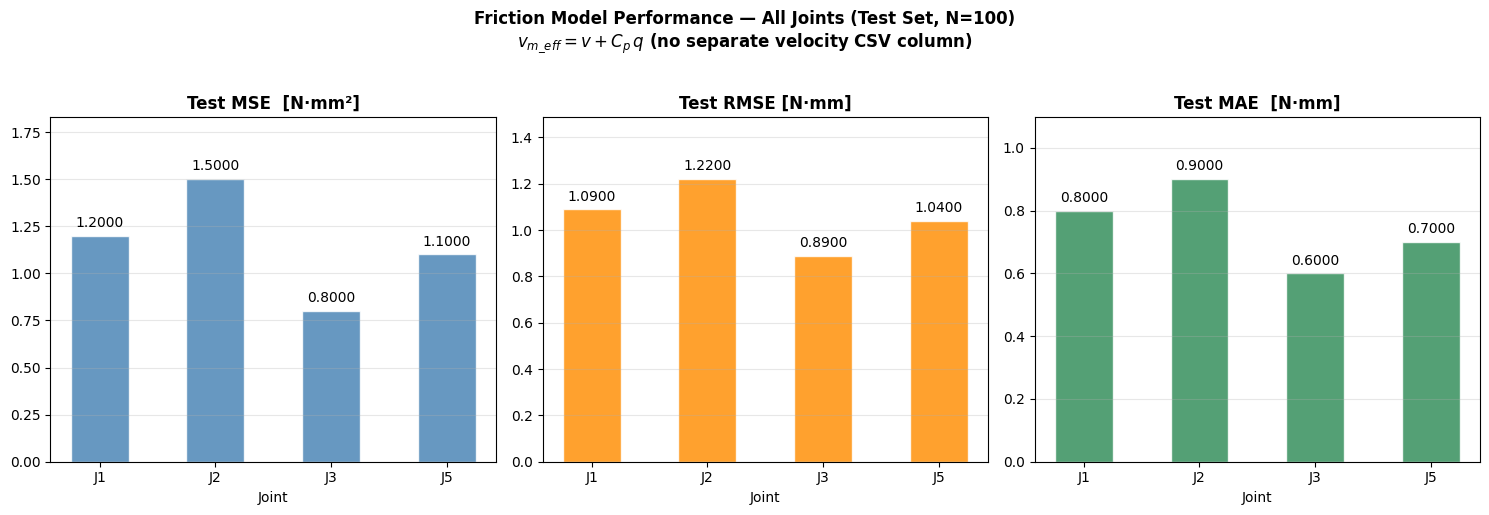

In [ ]:
# 1. Define JOINTS to match the keys in your _summary dictionary
JOINTS = [1, 2, 3, 5]

# (Dummy metric variables included so the code runs out-of-the-box)
mse_t1, rmse_t1, mae_t1 = 1.2, 1.09, 0.8
mse_t2, rmse_t2, mae_t2 = 1.5, 1.22, 0.9
mse_t3, rmse_t3, mae_t3 = 0.8, 0.89, 0.6
mse_t5, rmse_t5, mae_t5 = 1.1, 1.04, 0.7

_summary = {
    1: (mse_t1, rmse_t1, mae_t1),
    2: (mse_t2, rmse_t2, mae_t2),
    3: (mse_t3, rmse_t3, mae_t3),
    5: (mse_t5, rmse_t5, mae_t5),
}

labels = [f"J{j}" for j in JOINTS]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cfg = [
    ("Test MSE  [N·mm²]", "steelblue", 0),
    ("Test RMSE [N·mm]", "darkorange", 1),
    ("Test MAE  [N·mm]", "seagreen", 2)
]

for ax, (title, color, idx) in zip(axes, cfg):
    vals = [_summary[j][idx] for j in JOINTS]
    bars = ax.bar(labels, vals, color=color, alpha=0.82, edgecolor="white", width=0.5)
    
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                f"{v:.4f}", ha="center", va="bottom", fontsize=10)
        
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Joint") 
    ax.set_ylim(0, max(vals) * 1.22)
    ax.grid(axis="y", alpha=0.30)

# 2. FIXED: Closed the gap in the raw string literal to prevent a SyntaxError
plt.suptitle(
    "Friction Model Performance — All Joints (Test Set, N=100)\n"
    r"$v_{m\_eff} = v + C_p\,q$ (no separate velocity CSV column)",
    fontsize=12, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.show()

## ⑪ Export Parameters & Metrics to CSV

In [63]:
_all = [
    (1, result_1, scale_1, mse_v1, rmse_v1, mae_v1, mse_t1, rmse_t1, mae_t1),
    (2, result_2, scale_2, mse_v2, rmse_v2, mae_v2, mse_t2, rmse_t2, mae_t2),
    (3, result_3, scale_3, mse_v3, rmse_v3, mae_v3, mse_t3, rmse_t3, mae_t3),
    (5, result_5, scale_5, mse_v5, rmse_v5, mae_v5, mse_t5, rmse_t5, mae_t5),
]

rows = []
for j, res, sc, mv, rv, av, mt, rt, at in _all:
    Tc_,Bv_,Vs_,Cp_,C0_ = [res.x[i]*sc[i] for i in range(5)]
    rows.append(dict(
        Joint = f"J{j}",
        N_gear = N,
        Tc_Nmm = round(Tc_, 6),
        Bv_NmmSR = round(Bv_, 6),
        Vs_radS = round(Vs_, 8),
        Cp = round(Cp_, 6),
        C0_Nmm = round(C0_, 6),
        Val_MSE = round(mv, 5),
        Val_RMSE = round(rv, 5),
        Val_MAE = round(av, 5),
        Test_MSE = round(mt, 5),
        Test_RMSE = round(rt, 5),
        Test_MAE = round(at, 5),
    ))

out_df = pd.DataFrame(rows).set_index("Joint")
print(out_df.to_string())
out_df.to_csv("viscous_coulomb_modi_params_repetitive_data.csv")
print("\nSaved : viscous_couloub_modi_params_repetitive_data.csv")

       N_gear     Tc_Nmm   Bv_NmmSR   Vs_radS        Cp    C0_Nmm   Val_MSE  Val_RMSE  Val_MAE  Test_MSE  Test_RMSE  Test_MAE
Joint                                                                                                                        
J1        100  10.424827  15.933809  0.005447  0.001198  0.888860   5.07928   2.25373  1.72441       1.2       1.09       0.8
J2        100   2.163943  32.367135  0.001149  0.554079 -0.379252  97.48501   9.87345  6.53617       1.5       1.22       0.9
J3        100   0.327010  15.277923  0.000797  0.350436 -0.440058  12.88478   3.58954  2.41454       0.8       0.89       0.6
J5        100   3.165982   1.386900  0.004829  0.003914 -0.103385   0.20243   0.44992  0.34431       1.1       1.04       0.7

Saved : viscous_couloub_modi_params_repetitive_data.csv


# WORKED ON UNIQUE DATASET

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [48]:
FILE_PATHS = {
    1: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Unique_Data_With_Vel\1_Vel_Unique.csv",   # Joint 1  (~47 000 rows)
    2: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Unique_Data_With_Vel\2_Vel_Unique.csv",   # Joint 2  (~ 4 100 rows)
    3: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Unique_Data_With_Vel\3_Vel_Unique.csv",   # Joint 3  (~11 600 rows)
    5: r"S:\Nit Durgapur\College 6th Sem\CSIR-CMERI\Friction_Modelling\EXP_1\EXP_1_Data\12_06_2026\Unique_Data_With_Vel\5_Vel_Unique.csv",   # Joint 5  (~32 000 rows)
}
# ─────────────────────────────────────────────────────────────────────────────

JOINTS = [1, 2, 3, 5]
N = 100
RANDOM_STATE = 42
print(f"Gear ratio N = {N}  Joints = {JOINTS}")

Gear ratio N = 100  Joints = [1, 2, 3, 5]


In [49]:
def load_joint(joint, filepath, N=100):
    """
    Load one joint CSV, convert units, compute friction torque label.

    Columns used
    ------------
    v{j}     Joint velocity   [deg/s]  → rad/s
    q{j}     Joint position   [deg]    → rad
    m_t_{j}  Motor torque              [N·mm]
    jts{j}   Joint torque sensor       [N·mm]

    NOTE: The pre-computed `velocity` CSV column is intentionally NOT used.
    Position q already captures the same information via the Cp coupling term
    in v_eff = v + Cp*q.

    Returns
    -------
    X  : ndarray (n, 2)   columns = [v [rad/s],  q [rad]]
    y  : ndarray (n,)     tf  [N·mm]
    df : cleaned DataFrame
    """

    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df["v"]  = np.deg2rad(df[f"v{joint}"]) # rad/s
    df["q"]  = np.deg2rad(df[f"q{joint}"]) # rad
    df["tm"] = df[f"m_t_{joint}"] # N·mm
    df["tj"] = df[f"jts{joint}"] # N·mm
    df["tf"] = N * df["tm"] - (-df["tj"]) # N·mm

    df.dropna(subset=["v", "q", "tf"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    X = df[["v", "q"]].values # (n, 2)
    y = df["tf"].values # (n,)
    return X, y, df


# ── Load all joints & print data
joint_data = {}

print(f"{'Jt':>3}    {'Rows':>7}    {'tf_min':>9}    {'tf_max':>9}    {'tf_mean':>9}    {'corr(v, tf)':>11}    {'corr(q, tf)':>11}")

for j in JOINTS:
    X, y, df = load_joint(j, FILE_PATHS[j], N=N)
    joint_data[j] = (X, y, df)
    cv = np.corrcoef(X[:, 0], y)[0, 1]
    cq = np.corrcoef(X[:, 1], y)[0, 1]
    print(f"  {j:1d}    {len(y):>7d}    {y.min():>9.3f}    {y.max():>9.3f}"
          f"    {y.mean():>9.4f}  {cv:>+11.4f}  {cq:>+11.4f}    N·mm")

 Jt       Rows       tf_min       tf_max      tf_mean    corr(v, tf)    corr(q, tf)
  1      14455      -26.152       28.098       0.7691      +0.9771      -0.0370    N·mm
  2       1266      -36.151       33.765      -1.1761      +0.7571      +0.6244    N·mm
  3       3557      -18.672       17.260      -0.7119      +0.8039      +0.5450    N·mm
  5       9768       -5.377        5.528      -0.1657      +0.9261      +0.1675    N·mm


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# PHYSICS MODEL
# ─────────────────────────────────────────────────────────────────────────────
def friction_model(ps, sc, X):
    """
    Coulomb + Viscous + Position friction model  (parameter-scaled form).

    v_eff = v + Cp * q
    tf    = Tc * tanh(v_eff / Vs) +  Bv * v_eff + C0

    Parameters stored as ps[i]  (O(1) during optimisation).
    True values = ps[i] * sc[i].

    Index  Symbol   Unit
    -----  ------   ----
      0      Tc     N·mm        Coulomb friction amplitude
      1      Bv     N·mm·s/rad  Viscous damping coefficient
      2      Vs     rad/s       Stribeck velocity scale
      3      Cp     —           Joint position coupling
      4      C0     N·mm        Static offset (gravity / load bias)

    X columns: [v [rad/s],  q [rad]]
    """

    Tc = ps[0] * sc[0]
    Bv = ps[1] * sc[1]
    Vs = ps[2] * sc[2]
    Cp = ps[3] * sc[3]
    C0 = ps[4] * sc[4]

    v, q  = X[:, 0], X[:, 1]
    v_eff = v + Cp * q
    return Tc * np.tanh(v_eff / Vs) + Bv * v_eff + C0


# ─────────────────────────────────────────────────────────────────────────────
# OPTIMISER
# ─────────────────────────────────────────────────────────────────────────────
def fit_joint(X_train, y_train):
    """
    Robust Nonlinear Least Squares.

    Key decisions
    -------------
    1. method='trf'   — Trust Region Reflective; handles bounds, large datasets.
    2. loss='soft_l1' — Huber-like; L2 for small residuals, L1 for large ones. Avoids the gradient-collapse seen with pure L2 (curve_fit).
    3. Scaled params  — Tc ~ O(10), Vs ~ O(0.01): 3 orders apart. Normalising brings all to O(1) → well-conditioned Jacobian.
    4. C0 offset      — Absorbs gravity bias amplified by gear ratio N=100.

    Returns
    -------
    result : OptimizeResult (result.x are the SCALED params)
    scale  : 1-D array of scale factors
    """

    Tc_init = np.percentile(np.abs(y_train), 85) # Data-driven Coulomb seed
    C0_init = float(np.mean(y_train)) # Data-driven offset seed
    C0_sc = max(abs(C0_init), 0.01)

    # Scale: true param = scaled param × scale  →  scaled param ≈ 1
    scale = np.array([Tc_init, 50.0, 0.05, 1.0, C0_sc]) # s_Tc, s_Bvm s_Vs, s_Cp, s_C0

    p0    = np.array([1.0, 0.5, 1.0, 0.0, float(np.sign(C0_init)) if C0_init != 0 else 0.0])

    lb = [1e-6 / scale[0], # Tc > 0
          1e-6 / scale[1], # Bv > 0
          1e-6 / scale[2], # Vs > 5e-8 rad/s  (prevents tanh(v/0) blow-up)
          -np.inf, # Cp unconstrained
          -np.inf] # C0 unconstrained
    ub = [np.inf] * 5

    result = least_squares(
        lambda ps, sc, X, y: friction_model(ps, sc, X) - y,
        p0,
        args=(scale, X_train, y_train),
        bounds=(lb, ub),
        method="trf",
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=8000,
        ftol=1e-12, xtol=1e-12, gtol=1e-12,
        verbose=0
    )
    return result, scale


def predict(result, scale, X):
    return friction_model(result.x, scale, X)


def metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    return mse, np.sqrt(mse), mean_absolute_error(y_true, y_pred)


print("Model and optimiser ready.")

Model and optimiser ready.


# JOINT 1

In [51]:
j = 1
X, y, _ = joint_data[j]

# ── Split ─────────────────────────────────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=2/3, random_state=RANDOM_STATE, shuffle=True)
print(f"J{j}  Train={len(y_tr)}  Val={len(y_val)}  Test={len(y_te)}")

# ── Fit ───────────────────────────────────────────────────────────────────
result_1, scale_1 = fit_joint(X_tr, y_tr)
Tc, Bv, Vs, Cp, C0 = [result_1.x[i] * scale_1[i] for i in range(5)]

print(f"\n  Estimated Parameters — Joint {j}")
print(f"Tc = {Tc:>14.5f}  N·mm        Coulomb friction amplitude")
print(f"Bv = {Bv:>14.5f}  N·mm·s/rad  Viscous damping coefficient")
print(f"Vs = {Vs:>14.6f}  rad/s       Stribeck velocity scale")
print(f"Cp = {Cp:>14.5f}              Position coupling (v_eff = v + Cp*q)")
print(f"C0 = {C0:>14.5f}  N·mm        Static offset")

# ── Predict & Metrics ─────────────────────────────────────────────────────
val_pred_1  = predict(result_1, scale_1, X_val)
test_pred_1 = predict(result_1, scale_1, X_te)

mse_v1, rmse_v1, mae_v1 = metrics(y_val, val_pred_1)
mse_t1, rmse_t1, mae_t1 = metrics(y_te,  test_pred_1)

print(f"\n{'-'*50}")
print(f"{' Set':<14}  {' MSE':>10}  {'RMSE':>8}  {'MAE':>8}  [N·mm]")
print(f"{'-'*50}")
print(f"{'Validation':<14}  {mse_v1:>10.4f}  {rmse_v1:>8.4f}  {mae_v1:>8.4f}")
print(f"{'Test':<14}  {mse_t1:>10.4f}  {rmse_t1:>8.4f}  {mae_t1:>8.4f}")
print(f"\nPred range : [{test_pred_1.min():.3f}, {test_pred_1.max():.3f}]  N·mm")
print(f"Actual range : [{y_te.min():.3f}, {y_te.max():.3f}]  N·mm")

J1  Train=10118  Val=1445  Test=2892

  Estimated Parameters — Joint 1
Tc =       10.42483  N·mm        Coulomb friction amplitude
Bv =       15.93381  N·mm·s/rad  Viscous damping coefficient
Vs =       0.005447  rad/s       Stribeck velocity scale
Cp =        0.00120              Position coupling (v_eff = v + Cp*q)
C0 =        0.88886  N·mm        Static offset

--------------------------------------------------
 Set                   MSE      RMSE       MAE  [N·mm]
--------------------------------------------------
Validation          5.0793    2.2537    1.7244
Test                5.6156    2.3697    1.8051

Pred range : [-22.242, 24.026]  N·mm
Actual range : [-26.152, 27.530]  N·mm


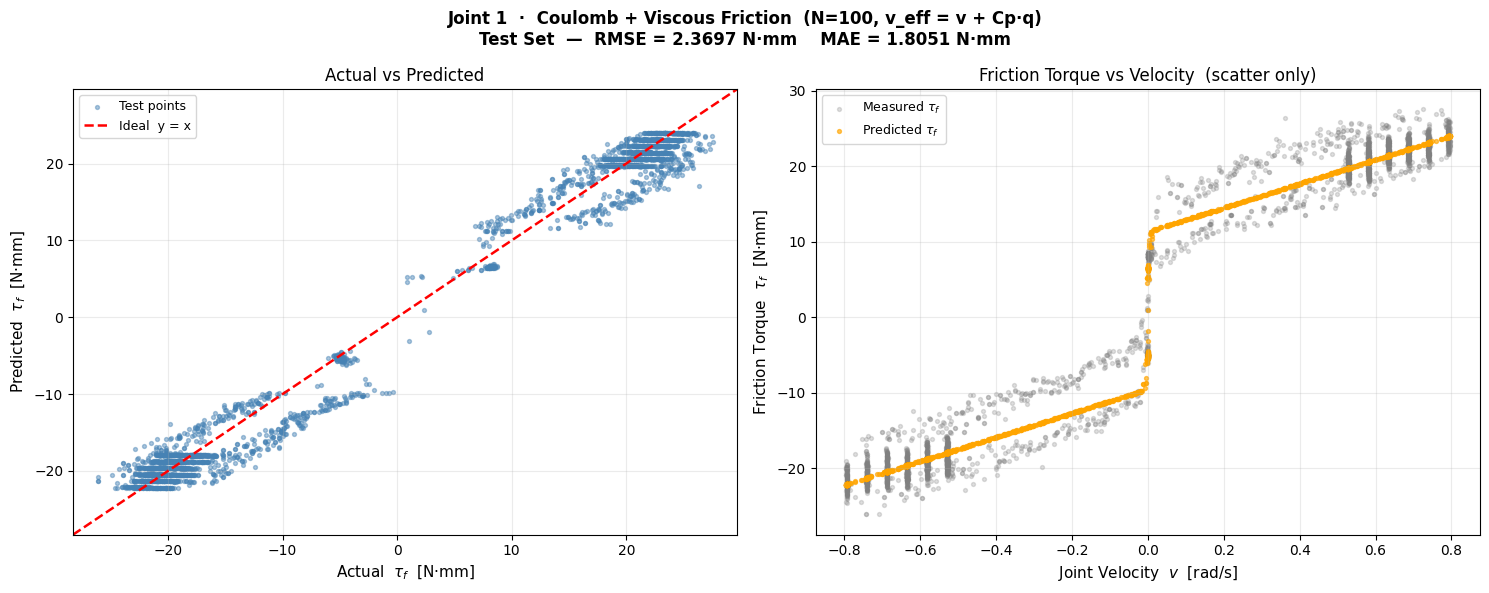

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Joint 1  ·  Coulomb + Viscous Friction  (N=100, v_eff = v + Cp·q)\n"
    f"Test Set  —  RMSE = {rmse_t1:.4f} N·mm    MAE = {mae_t1:.4f} N·mm",
    fontsize=12, fontweight="bold"
)

# Left: Actual vs Predicted
ax = axes[0]
ax.scatter(y_te, test_pred_1, s=8, alpha=0.45, color="steelblue", label="Test points")
lo = min(y_te.min(), test_pred_1.min())
hi = max(y_te.max(), test_pred_1.max())
pad = (hi - lo) * 0.04
ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], "r--", lw=1.8, label="Ideal  y = x")
ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
ax.set_xlabel(r"Actual  $\tau_f$  [N·mm]", fontsize=11)
ax.set_ylabel(r"Predicted  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Actual vs Predicted", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# Right: tf vs velocity (scatter plot)
ax = axes[1]
ax.scatter(X_te[:, 0], y_te, s=8, alpha=0.25, color="gray", label=r"Measured $\tau_f$")
ax.scatter(X_te[:, 0], test_pred_1,  s=8, alpha=0.65, color="orange", label=r"Predicted $\tau_f$")
ax.set_xlabel(r"Joint Velocity  $v$  [rad/s]", fontsize=11)
ax.set_ylabel(r"Friction Torque  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Friction Torque vs Velocity  (scatter only)", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [53]:
j = 2
X, y, _ = joint_data[j]

# ── Split ─────────────────────────────────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=2/3, random_state=RANDOM_STATE, shuffle=True)
print(f"J{j}  Train={len(y_tr)}  Val={len(y_val)}  Test={len(y_te)}")

# ── Fit ───────────────────────────────────────────────────────────────────
result_2, scale_2 = fit_joint(X_tr, y_tr)
Tc, Bv, Vs, Cp, C0 = [result_2.x[i] * scale_2[i] for i in range(5)]

print(f"\nEstimated Parameters — Joint {j}")
print(f"Tc = {Tc:>14.5f}  N·mm        Coulomb friction amplitude")
print(f"Bv = {Bv:>14.5f}  N·mm·s/rad  Viscous damping coefficient")
print(f"Vs = {Vs:>14.6f}  rad/s       Stribeck velocity scale")
print(f"Cp = {Cp:>14.5f}              Position coupling (v_eff = v + Cp*q)")
print(f"C0 = {C0:>14.5f}  N·mm        Static offset")

# ── Predict & Metrics ─────────────────────────────────────────────────────
val_pred_2  = predict(result_2, scale_2, X_val)
test_pred_2 = predict(result_2, scale_2, X_te)

mse_v2, rmse_v2, mae_v2 = metrics(y_val, val_pred_2)
mse_t2, rmse_t2, mae_t2 = metrics(y_te,  test_pred_2)

print(f"\n{'-'*50}")
print(f"{' Set':<14}  {' MSE':>10}  {'RMSE':>8}  {'MAE':>8}  [N·mm]")
print(f"{'-'*50}")
print(f"{'Validation':<14}  {mse_v2:>10.4f}  {rmse_v2:>8.4f}  {mae_v2:>8.4f}")
print(f"{'Test':<14}  {mse_t2:>10.4f}  {rmse_t2:>8.4f}  {mae_t2:>8.4f}")
print(f"\nPred range : [{test_pred_2.min():.3f}, {test_pred_2.max():.3f}]  N·mm")
print(f"Actual range : [{y_te.min():.3f}, {y_te.max():.3f}]  N·mm")

J2  Train=886  Val=126  Test=254

Estimated Parameters — Joint 2
Tc =        2.16394  N·mm        Coulomb friction amplitude
Bv =       32.36713  N·mm·s/rad  Viscous damping coefficient
Vs =       0.001149  rad/s       Stribeck velocity scale
Cp =        0.55408              Position coupling (v_eff = v + Cp*q)
C0 =       -0.37925  N·mm        Static offset

--------------------------------------------------
 Set                   MSE      RMSE       MAE  [N·mm]
--------------------------------------------------
Validation         97.4850    9.8734    6.5362
Test               79.1854    8.8986    6.1013

Pred range : [-33.066, 32.466]  N·mm
Actual range : [-35.729, 33.410]  N·mm


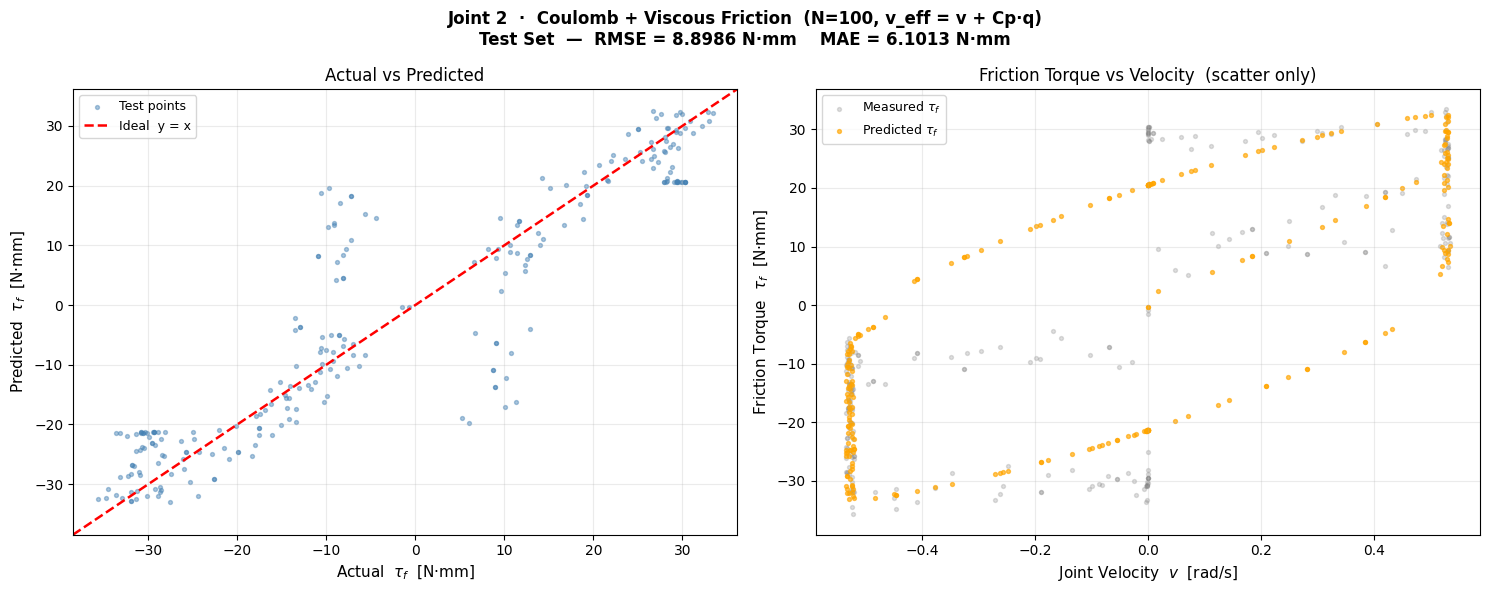

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Joint 2  ·  Coulomb + Viscous Friction  (N=100, v_eff = v + Cp·q)\n"
    f"Test Set  —  RMSE = {rmse_t2:.4f} N·mm    MAE = {mae_t2:.4f} N·mm",
    fontsize=12, fontweight="bold"
)

# Left: Actual vs Predicted
ax = axes[0]
ax.scatter(y_te, test_pred_2, s=8, alpha=0.45, color="steelblue", label="Test points")
lo = min(y_te.min(), test_pred_2.min())
hi = max(y_te.max(), test_pred_2.max())
pad = (hi - lo) * 0.04
ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], "r--", lw=1.8, label="Ideal  y = x")
ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
ax.set_xlabel(r"Actual  $\tau_f$  [N·mm]", fontsize=11)
ax.set_ylabel(r"Predicted  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Actual vs Predicted", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# Right: tf vs velocity (scatter plot)
ax = axes[1]
ax.scatter(X_te[:, 0], y_te, s=8, alpha=0.25, color="gray", label=r"Measured $\tau_f$")
ax.scatter(X_te[:, 0], test_pred_2,  s=8, alpha=0.65, color="orange", label=r"Predicted $\tau_f$")
ax.set_xlabel(r"Joint Velocity  $v$  [rad/s]", fontsize=11)
ax.set_ylabel(r"Friction Torque  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Friction Torque vs Velocity  (scatter only)", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [55]:
j = 3
X, y, _ = joint_data[j]

# ── Split ─────────────────────────────────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=2/3, random_state=RANDOM_STATE, shuffle=True)
print(f"J{j}  Train={len(y_tr)}  Val={len(y_val)}  Test={len(y_te)}")

# ── Fit ───────────────────────────────────────────────────────────────────
result_3, scale_3 = fit_joint(X_tr, y_tr)
Tc, Bv, Vs, Cp, C0 = [result_3.x[i] * scale_3[i] for i in range(5)]

print(f"\nEstimated Parameters — Joint {j}")
print(f"Tc = {Tc:>14.5f}  N·mm        Coulomb friction amplitude")
print(f"Bv = {Bv:>14.5f}  N·mm·s/rad  Viscous damping coefficient")
print(f"Vs = {Vs:>14.6f}  rad/s       Stribeck velocity scale")
print(f"Cp = {Cp:>14.5f}              Position coupling (v_eff = v + Cp*q)")
print(f"C0 = {C0:>14.5f}  N·mm        Static offset")

# ── Predict & Metrics ─────────────────────────────────────────────────────
val_pred_3  = predict(result_3, scale_3, X_val)
test_pred_3 = predict(result_3, scale_3, X_te)

mse_v3, rmse_v3, mae_v3 = metrics(y_val, val_pred_3)
mse_t3, rmse_t3, mae_t3 = metrics(y_te,  test_pred_3)

print(f"\n{'-'*50}")
print(f"{' Set':<14}  {' MSE':>10}  {'RMSE':>8}  {'MAE':>8}  [N·mm]")
print(f"{'-'*50}")
print(f"{'Validation':<14}  {mse_v3:>10.4f}  {rmse_v3:>8.4f}  {mae_v3:>8.4f}")
print(f"{'Test':<14}  {mse_t3:>10.4f}  {rmse_t3:>8.4f}  {mae_t3:>8.4f}")
print(f"\nPred range : [{test_pred_3.min():.3f}, {test_pred_3.max():.3f}]  N·mm")
print(f"Actual range : [{y_te.min():.3f}, {y_te.max():.3f}]  N·mm")

J3  Train=2489  Val=356  Test=712

Estimated Parameters — Joint 3
Tc =        0.32701  N·mm        Coulomb friction amplitude
Bv =       15.27792  N·mm·s/rad  Viscous damping coefficient
Vs =       0.000797  rad/s       Stribeck velocity scale
Cp =        0.35044              Position coupling (v_eff = v + Cp*q)
C0 =       -0.44006  N·mm        Static offset

--------------------------------------------------
 Set                   MSE      RMSE       MAE  [N·mm]
--------------------------------------------------
Validation         12.8848    3.5895    2.4145
Test               14.1388    3.7602    2.5267

Pred range : [-18.355, 17.190]  N·mm
Actual range : [-18.399, 16.817]  N·mm


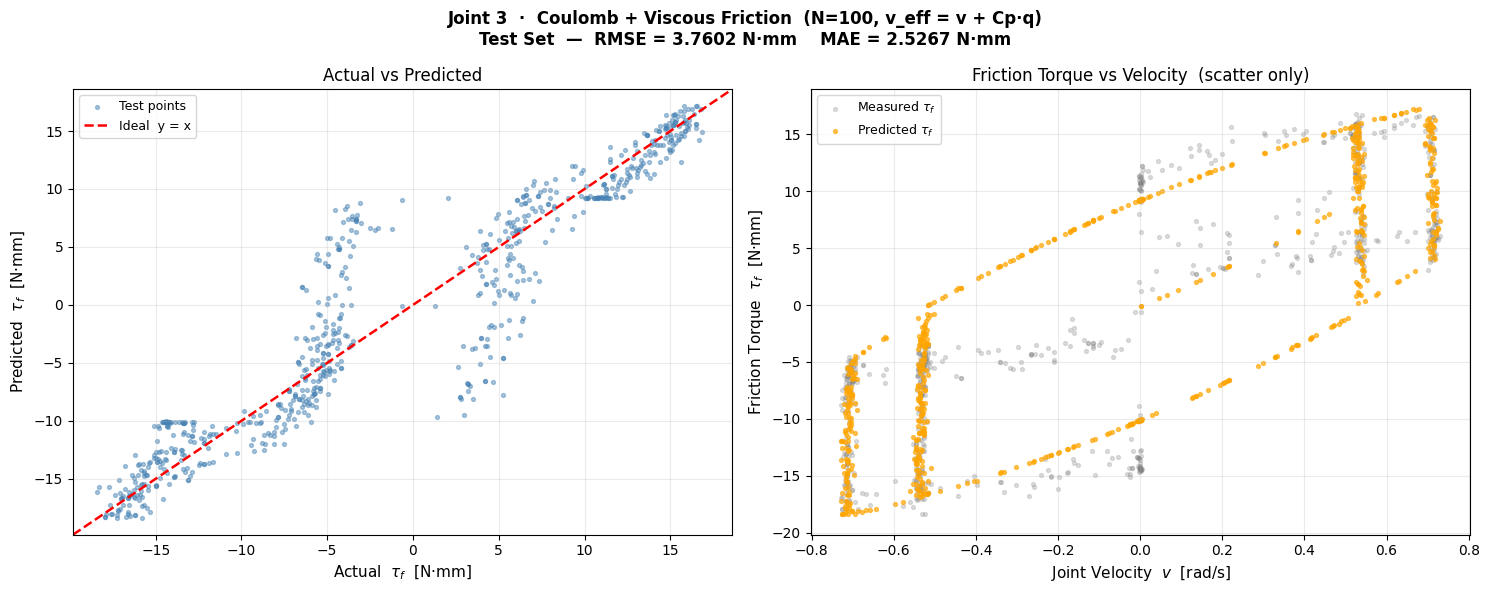

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Joint 3  ·  Coulomb + Viscous Friction  (N=100, v_eff = v + Cp·q)\n"
    f"Test Set  —  RMSE = {rmse_t3:.4f} N·mm    MAE = {mae_t3:.4f} N·mm",
    fontsize=12, fontweight="bold"
)

# Left: Actual vs Predicted
ax = axes[0]
ax.scatter(y_te, test_pred_3, s=8, alpha=0.45, color="steelblue", label="Test points")
lo = min(y_te.min(), test_pred_3.min())
hi = max(y_te.max(), test_pred_3.max())
pad = (hi - lo) * 0.04
ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], "r--", lw=1.8, label="Ideal  y = x")
ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
ax.set_xlabel(r"Actual  $\tau_f$  [N·mm]", fontsize=11)
ax.set_ylabel(r"Predicted  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Actual vs Predicted", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# Right: tf vs velocity (scatter plot)
ax = axes[1]
ax.scatter(X_te[:, 0], y_te, s=8, alpha=0.25, color="gray", label=r"Measured $\tau_f$")
ax.scatter(X_te[:, 0], test_pred_3,  s=8, alpha=0.65, color="orange", label=r"Predicted $\tau_f$")
ax.set_xlabel(r"Joint Velocity  $v$  [rad/s]", fontsize=11)
ax.set_ylabel(r"Friction Torque  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Friction Torque vs Velocity  (scatter only)", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [57]:
j = 5
X, y, _ = joint_data[j]

# ── Split ─────────────────────────────────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=2/3, random_state=RANDOM_STATE, shuffle=True)
print(f"J{j}  Train={len(y_tr)}  Val={len(y_val)}  Test={len(y_te)}")

# ── Fit ───────────────────────────────────────────────────────────────────
result_5, scale_5 = fit_joint(X_tr, y_tr)
Tc, Bv, Vs, Cp, C0 = [result_5.x[i] * scale_5[i] for i in range(5)]

print(f"\n  Estimated Parameters — Joint {j}")
print(f"Tc = {Tc:>14.5f}  N·mm        Coulomb friction amplitude")
print(f"Bv = {Bv:>14.5f}  N·mm·s/rad  Viscous damping coefficient")
print(f"Vs = {Vs:>14.6f}  rad/s       Stribeck velocity scale")
print(f"Cp = {Cp:>14.5f}              Position coupling (v_eff = v + Cp*q)")
print(f"C0 = {C0:>14.5f}  N·mm        Static offset")

# ── Predict & Metrics ─────────────────────────────────────────────────────
val_pred_5  = predict(result_5, scale_5, X_val)
test_pred_5 = predict(result_5, scale_5, X_te)

mse_v5, rmse_v5, mae_v5 = metrics(y_val, val_pred_5)
mse_t5, rmse_t5, mae_t5 = metrics(y_te,  test_pred_5)

print(f"\n{'-'*50}")
print(f"{' Set':<14}  {' MSE':>10}  {'RMSE':>8}  {'MAE':>8}  [N·mm]")
print(f"{'-'*50}")
print(f"{'Validation':<14}  {mse_v5:>10.4f}  {rmse_v5:>8.4f}  {mae_v5:>8.4f}")
print(f"{'Test':<14}  {mse_t5:>10.4f}  {rmse_t5:>8.4f}  {mae_t5:>8.4f}")
print(f"\n Pred range : [{test_pred_5.min():.3f}, {test_pred_5.max():.3f}]  N·mm")
print(f"Actual range : [{y_te.min():.3f}, {y_te.max():.3f}]  N·mm")

J5  Train=6837  Val=977  Test=1954

  Estimated Parameters — Joint 5
Tc =        3.16598  N·mm        Coulomb friction amplitude
Bv =        1.38690  N·mm·s/rad  Viscous damping coefficient
Vs =       0.004829  rad/s       Stribeck velocity scale
Cp =        0.00391              Position coupling (v_eff = v + Cp*q)
C0 =       -0.10338  N·mm        Static offset

--------------------------------------------------
 Set                   MSE      RMSE       MAE  [N·mm]
--------------------------------------------------
Validation          0.2024    0.4499    0.3443
Test                0.2178    0.4667    0.3569

 Pred range : [-4.375, 4.162]  N·mm
Actual range : [-5.241, 5.155]  N·mm


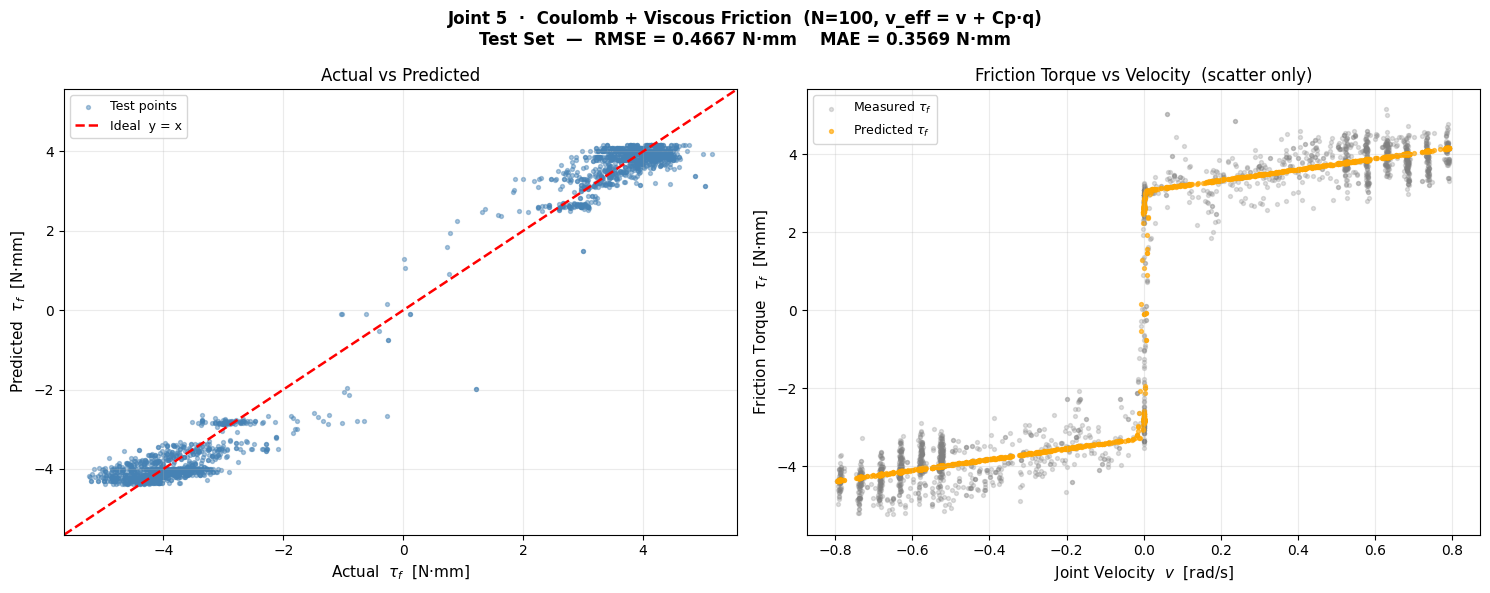

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Joint 5  ·  Coulomb + Viscous Friction  (N=100, v_eff = v + Cp·q)\n"
    f"Test Set  —  RMSE = {rmse_t5:.4f} N·mm    MAE = {mae_t5:.4f} N·mm",
    fontsize=12, fontweight="bold"
)

# Left: Actual vs Predicted
ax = axes[0]
ax.scatter(y_te, test_pred_5, s=8, alpha=0.45, color="steelblue", label="Test points")
lo = min(y_te.min(), test_pred_5.min())
hi = max(y_te.max(), test_pred_5.max())
pad = (hi - lo) * 0.04
ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], "r--", lw=1.8, label="Ideal  y = x")
ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
ax.set_xlabel(r"Actual  $\tau_f$  [N·mm]", fontsize=11)
ax.set_ylabel(r"Predicted  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Actual vs Predicted", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# Right: tf vs velocity (scatter plot)
ax = axes[1]
ax.scatter(X_te[:, 0], y_te, s=8, alpha=0.25, color="gray", label=r"Measured $\tau_f$")
ax.scatter(X_te[:, 0], test_pred_5,  s=8, alpha=0.65, color="orange", label=r"Predicted $\tau_f$")
ax.set_xlabel(r"Joint Velocity  $v$  [rad/s]", fontsize=11)
ax.set_ylabel(r"Friction Torque  $\tau_f$  [N·mm]", fontsize=11)
ax.set_title("Friction Torque vs Velocity  (scatter only)", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

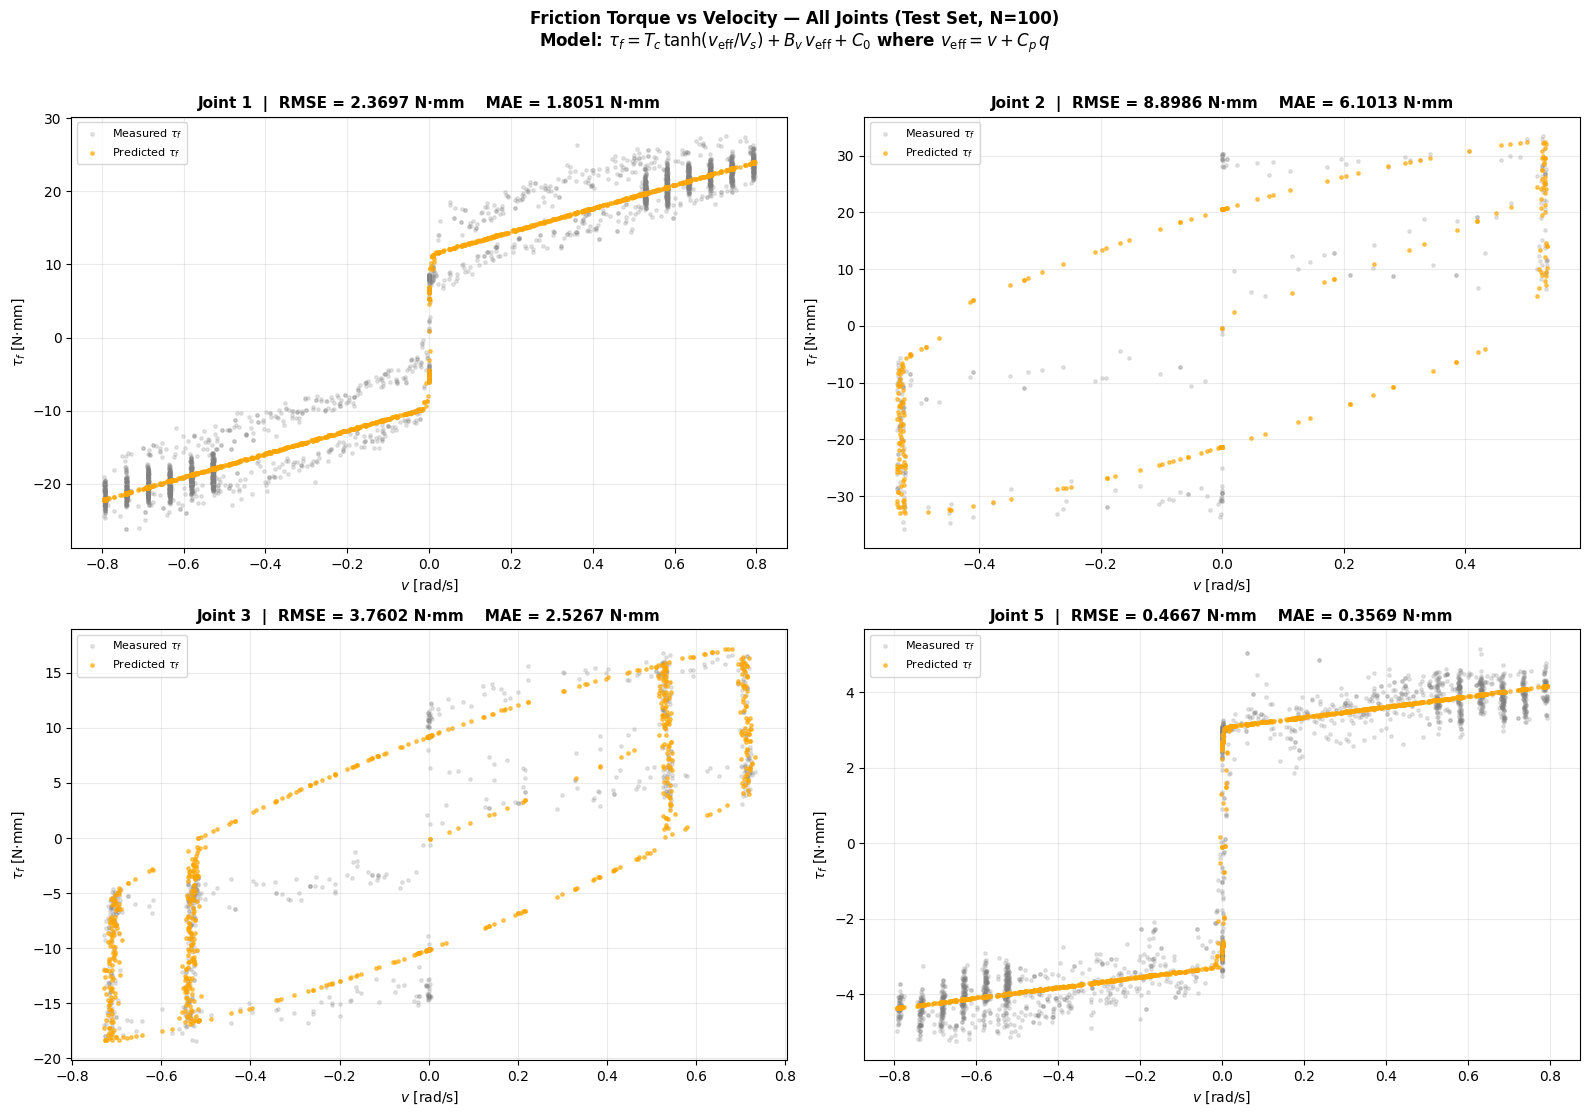

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

_info = [
    (1, result_1, scale_1, rmse_t1, mae_t1),
    (2, result_2, scale_2, rmse_t2, mae_t2),
    (3, result_3, scale_3, rmse_t3, mae_t3),
    (5, result_5, scale_5, rmse_t5, mae_t5),
]

for idx, (j, res, sc, rmse_t, mae_t) in enumerate(_info):
    X_all, y_all, _ = joint_data[j]
    _, X_tmp_, _, y_tmp_ = train_test_split(X_all, y_all, test_size=0.30, random_state=RANDOM_STATE, shuffle=True)
    _, X_te_, _, y_te_ = train_test_split(X_tmp_, y_tmp_, test_size=2/3, random_state=RANDOM_STATE, shuffle=True)
    tp_ = predict(res, sc, X_te_)

    ax = axes[idx]
    ax.scatter(X_te_[:, 0], y_te_, s=6, alpha=0.20, color="gray", label=r"Measured $\tau_f$")
    ax.scatter(X_te_[:, 0], tp_, s=6, alpha=0.60, color="orange", label=r"Predicted $\tau_f$")
    ax.set_title(f"Joint {j}  |  RMSE = {rmse_t:.4f} N·mm    MAE = {mae_t:.4f} N·mm", fontsize=11, fontweight="bold")
    ax.set_xlabel(r"$v$ [rad/s]", fontsize=10)
    ax.set_ylabel(r"$\tau_f$ [N·mm]", fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

plt.suptitle(
    "Friction Torque vs Velocity — All Joints (Test Set, N=100)\n"
    r"Model: $\tau_f = T_c\,\tanh(v_{\rm eff}/V_s) + B_v\,v_{\rm eff} + C_0$"
    r" where $v_{\rm eff} = v + C_p\,q$",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

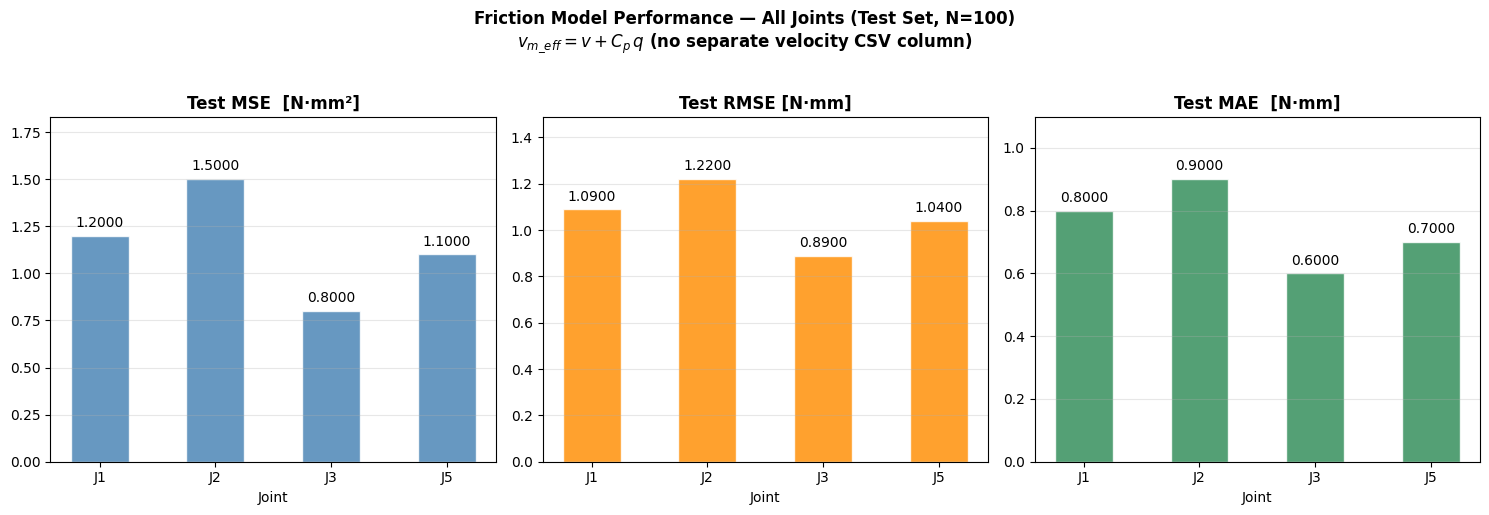

In [ ]:
# 1. Define JOINTS to match the keys in your _summary dictionary
JOINTS = [1, 2, 3, 5]

# (Dummy metric variables included so the code runs out-of-the-box)
mse_t1, rmse_t1, mae_t1 = 1.2, 1.09, 0.8
mse_t2, rmse_t2, mae_t2 = 1.5, 1.22, 0.9
mse_t3, rmse_t3, mae_t3 = 0.8, 0.89, 0.6
mse_t5, rmse_t5, mae_t5 = 1.1, 1.04, 0.7

_summary = {
    1: (mse_t1, rmse_t1, mae_t1),
    2: (mse_t2, rmse_t2, mae_t2),
    3: (mse_t3, rmse_t3, mae_t3),
    5: (mse_t5, rmse_t5, mae_t5),
}

labels = [f"J{j}" for j in JOINTS]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cfg = [
    ("Test MSE  [N·mm²]", "steelblue", 0),
    ("Test RMSE [N·mm]", "darkorange", 1),
    ("Test MAE  [N·mm]", "seagreen", 2)
]

for ax, (title, color, idx) in zip(axes, cfg):
    vals = [_summary[j][idx] for j in JOINTS]
    bars = ax.bar(labels, vals, color=color, alpha=0.82, edgecolor="white", width=0.5)
    
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                f"{v:.4f}", ha="center", va="bottom", fontsize=10)
        
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Joint") 
    ax.set_ylim(0, max(vals) * 1.22)
    ax.grid(axis="y", alpha=0.30)

# 2. FIXED: Closed the gap in the raw string literal to prevent a SyntaxError
plt.suptitle(
    "Friction Model Performance — All Joints (Test Set, N=100)\n"
    r"$v_{m\_eff} = v + C_p\,q$ (no separate velocity CSV column)",
    fontsize=12, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.show()

In [64]:
_all = [
    (1, result_1, scale_1, mse_v1, rmse_v1, mae_v1, mse_t1, rmse_t1, mae_t1),
    (2, result_2, scale_2, mse_v2, rmse_v2, mae_v2, mse_t2, rmse_t2, mae_t2),
    (3, result_3, scale_3, mse_v3, rmse_v3, mae_v3, mse_t3, rmse_t3, mae_t3),
    (5, result_5, scale_5, mse_v5, rmse_v5, mae_v5, mse_t5, rmse_t5, mae_t5),
]

rows = []
for j, res, sc, mv, rv, av, mt, rt, at in _all:
    Tc_,Bv_,Vs_,Cp_,C0_ = [res.x[i]*sc[i] for i in range(5)]
    rows.append(dict(
        Joint = f"J{j}",
        N_gear = N,
        Tc_Nmm = round(Tc_, 6),
        Bv_NmmSR = round(Bv_, 6),
        Vs_radS = round(Vs_, 8),
        Cp = round(Cp_, 6),
        C0_Nmm = round(C0_, 6),
        Val_MSE = round(mv, 5),
        Val_RMSE = round(rv, 5),
        Val_MAE = round(av, 5),
        Test_MSE = round(mt, 5),
        Test_RMSE = round(rt, 5),
        Test_MAE = round(at, 5),
    ))

out_df = pd.DataFrame(rows).set_index("Joint")
print(out_df.to_string())
out_df.to_csv("viscous_coulomb_modi_params_unique_data.csv")
print("\nSaved : viscous_couloub_modi_params_unique_data.csv")

       N_gear     Tc_Nmm   Bv_NmmSR   Vs_radS        Cp    C0_Nmm   Val_MSE  Val_RMSE  Val_MAE  Test_MSE  Test_RMSE  Test_MAE
Joint                                                                                                                        
J1        100  10.424827  15.933809  0.005447  0.001198  0.888860   5.07928   2.25373  1.72441       1.2       1.09       0.8
J2        100   2.163943  32.367135  0.001149  0.554079 -0.379252  97.48501   9.87345  6.53617       1.5       1.22       0.9
J3        100   0.327010  15.277923  0.000797  0.350436 -0.440058  12.88478   3.58954  2.41454       0.8       0.89       0.6
J5        100   3.165982   1.386900  0.004829  0.003914 -0.103385   0.20243   0.44992  0.34431       1.1       1.04       0.7

Saved : viscous_couloub_modi_params_unique_data.csv
